# 02 - Explicabilite et calibration des seuils

Ce notebook produit les figures d'explicabilite pour le rapport :
1. Importance globale des features (SHAP summary plot)
2. Explication d'un cas individuel (SHAP waterfall)
3. Heatmap par occlusion sur quelques images-types
4. Courbes de calibration et choix des seuils de decision

Pre-requis : avoir entraine `image_model_*.joblib` (script `train_image_model.py`).

In [17]:
# Cellule 1 : Mount + cwd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
os.chdir('/content/drive/MyDrive/Insurance-fraud-detection-AI/02_notebooks')
print("CWD =", os.getcwd())

# Cellule 2 : Dépendances
!pip install -q open_clip_torch transformers accelerate bitsandbytes shap matplotlib Pillow imagehash

# Cellule 3 et suivantes : le code original du notebook (VARIANT, MODEL_PATH, etc.)

Mounted at /content/drive
CWD = /content/drive/MyDrive/Insurance-fraud-detection-AI/02_notebooks
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


In [18]:
%matplotlib inline
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from PIL import Image

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / '03_src'))
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
FIG_DIR = ROOT / '06_reports/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Chargement modele image (variante full pour avoir toutes les features)

In [19]:
VARIANT = 'lite'    # 'full' si features LMM disponibles, sinon 'lite'
MODEL_PATH = ROOT / f'04_models/image_model_{VARIANT}.joblib'
if not MODEL_PATH.exists():
    fallback = ROOT / '04_models/image_model_lite.joblib'
    if fallback.exists():
        print(f"image_model_{VARIANT}.joblib absent, fallback sur lite")
        MODEL_PATH = fallback
        VARIANT = 'lite'
pkg = joblib.load(MODEL_PATH)
model = pkg['model']
scaler = pkg['scaler']
feature_names = pkg['feature_names']
print(f"Algo : {pkg['best_algo']}, features : {len(feature_names)}")

Algo : logreg, features : 770


In [20]:
# Reconstruire X_test pour SHAP
df_candidates = [
    ROOT / '01_data/processed/dataset_with_lmm.parquet',
    ROOT / '01_data/processed/dataset_with_blip2.parquet',
    ROOT / '01_data/processed/dataset_with_clip.parquet',
    ROOT / '01_data/processed/dataset.parquet',
]
df_path = next((p for p in df_candidates if p.exists()), None)
df = pd.read_parquet(df_path).reset_index(drop=True)
X_clip = np.load(ROOT / '04_models/clip_embeddings.npy')

n_clip = sum(1 for n in feature_names if n.startswith('clip_'))
extras = [n for n in feature_names if not n.startswith('clip_')]
extra_arrays = []
for c in extras:
    if c in df.columns:
        extra_arrays.append(df[c].astype(float).fillna(0.5).values.reshape(-1, 1))
    else:
        extra_arrays.append(np.full((len(df), 1), 0.5))
X_extra = np.hstack(extra_arrays) if extra_arrays else np.zeros((len(df), 0))
X = np.hstack([X_clip[:, :n_clip].astype(np.float32), X_extra.astype(np.float32)])
X_s = scaler.transform(X)
print(f'X shape : {X_s.shape}')

X shape : (31062, 770)


## 2. SHAP - importance globale

Pour les modeles tree-based (XGBoost, RandomForest), on utilise TreeExplainer (rapide).
Pour LogReg, LinearExplainer.

In [21]:
# On limite a un sous-echantillon pour la rapidite SHAP
mask_test = (df['split'] == 'generic_test').values
if mask_test.sum() == 0:
    print("Pas de generic_test, fallback sur tout le dataset")
    mask_test = np.ones(len(df), dtype=bool)
X_test = X_s[mask_test]
y_test = df.loc[mask_test, 'label'].values

sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

if pkg['best_algo'] in ('xgb', 'rf'):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)
else:
    explainer = shap.LinearExplainer(model, X_sample)
    shap_values = explainer(X_sample)

# Pour XGB binary, shap_values est un Explanation 2D (n_samples, n_features)
print('SHAP shape :', shap_values.shape)

SHAP shape : (500, 770)


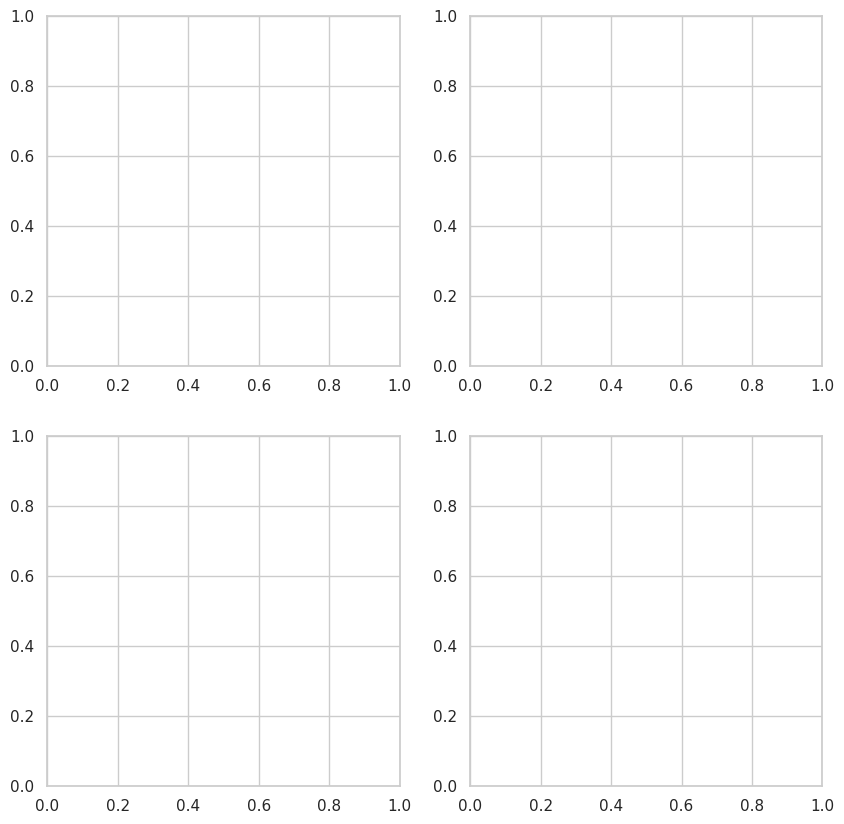

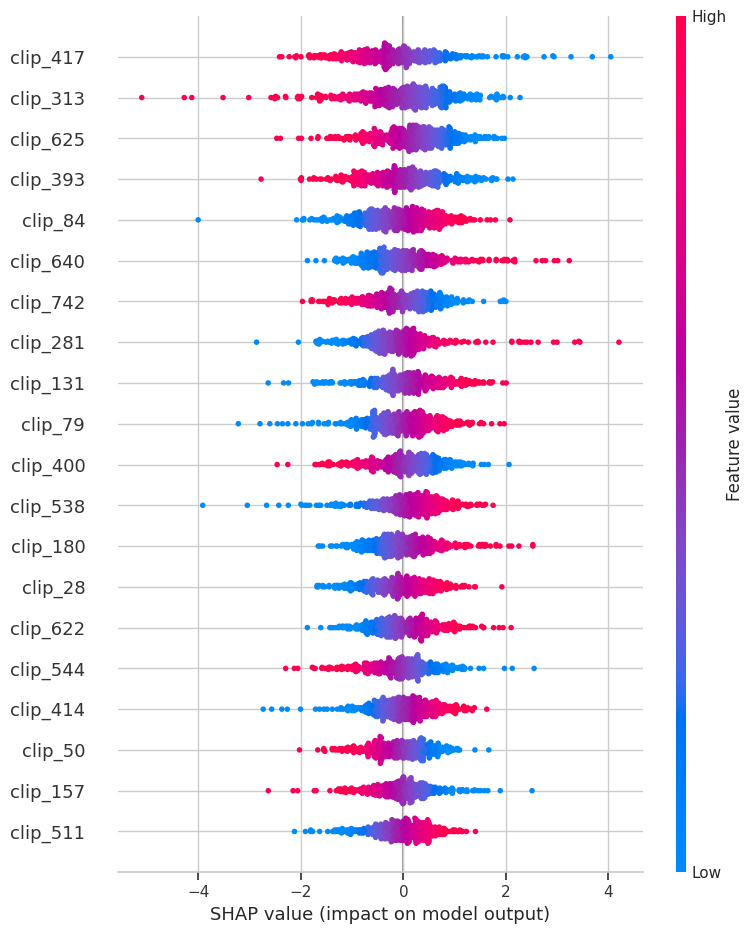

In [22]:
# Plot summary - top 20 features par importance
fig = plt.figure(figsize=(8, 8))
shap.summary_plot(
    shap_values, X_sample, feature_names=feature_names,
    max_display=20, show=False, plot_type='dot',
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_top20.png', dpi=150, bbox_inches='tight')
plt.show()

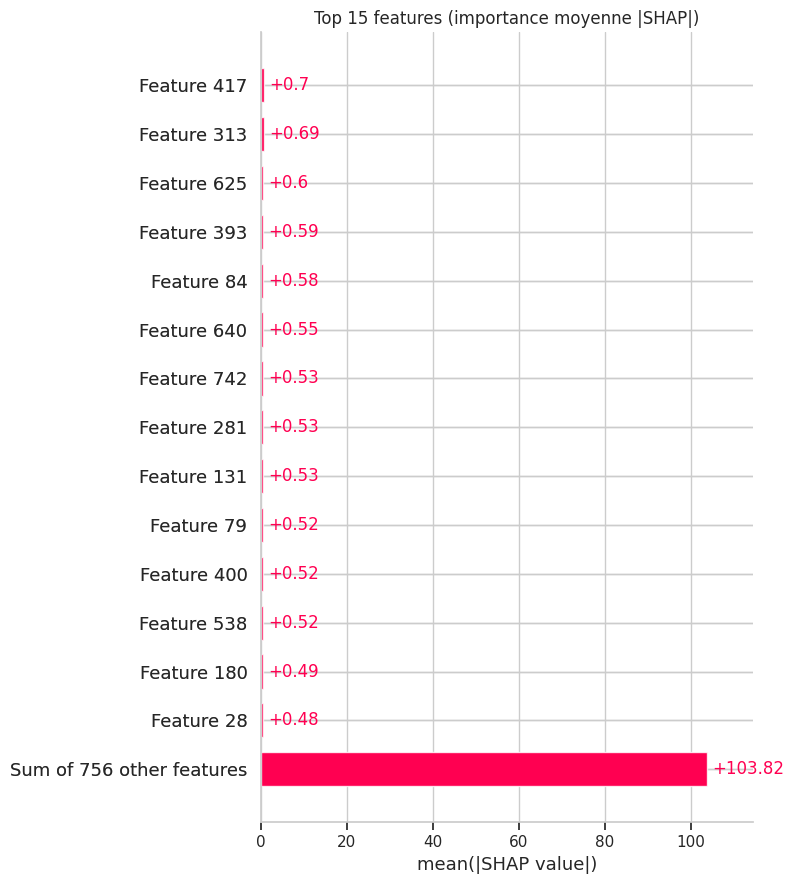

In [23]:
# Bar plot d'importance moyenne |SHAP|
fig = plt.figure(figsize=(8, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Top 15 features (importance moyenne |SHAP|)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. SHAP - cas individuel (waterfall)

Choisi un exemple ou le modele predit clairement la fraude (proba > 0.85).

Cas selectionne : proba fraude = 0.999, vrai label = 1


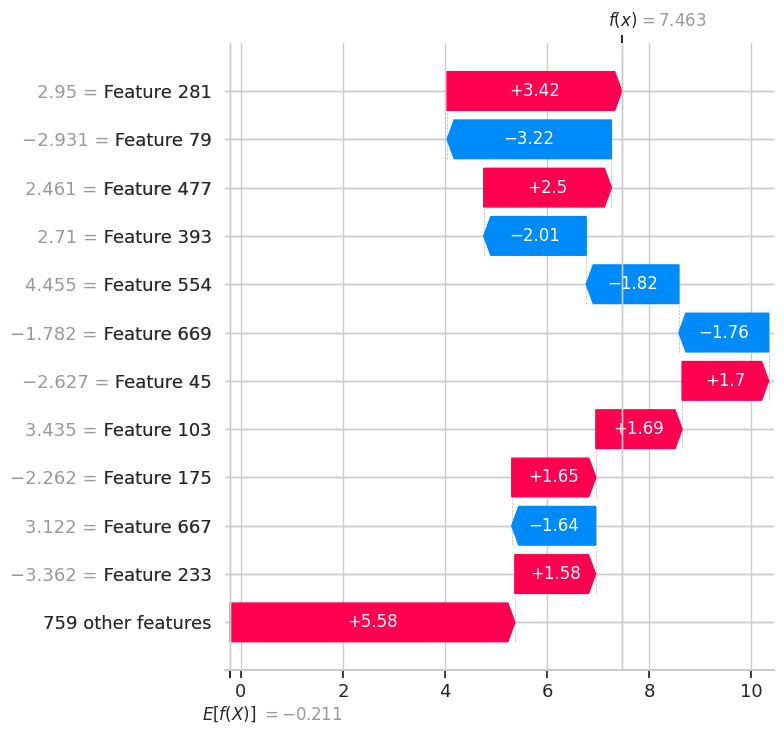

In [24]:
proba = model.predict_proba(X_sample)[:, 1]
high_idx = np.argsort(proba)[-1]
print(f'Cas selectionne : proba fraude = {proba[high_idx]:.3f}, vrai label = {y_sample[high_idx]}')

fig = plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[high_idx], max_display=12, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_waterfall_cas_fraude.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Occlusion sensitivity sur images-types

Selection d'une image reelle et d'une image synthetique du domaine habitation, et calcul de la heatmap d'importance.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


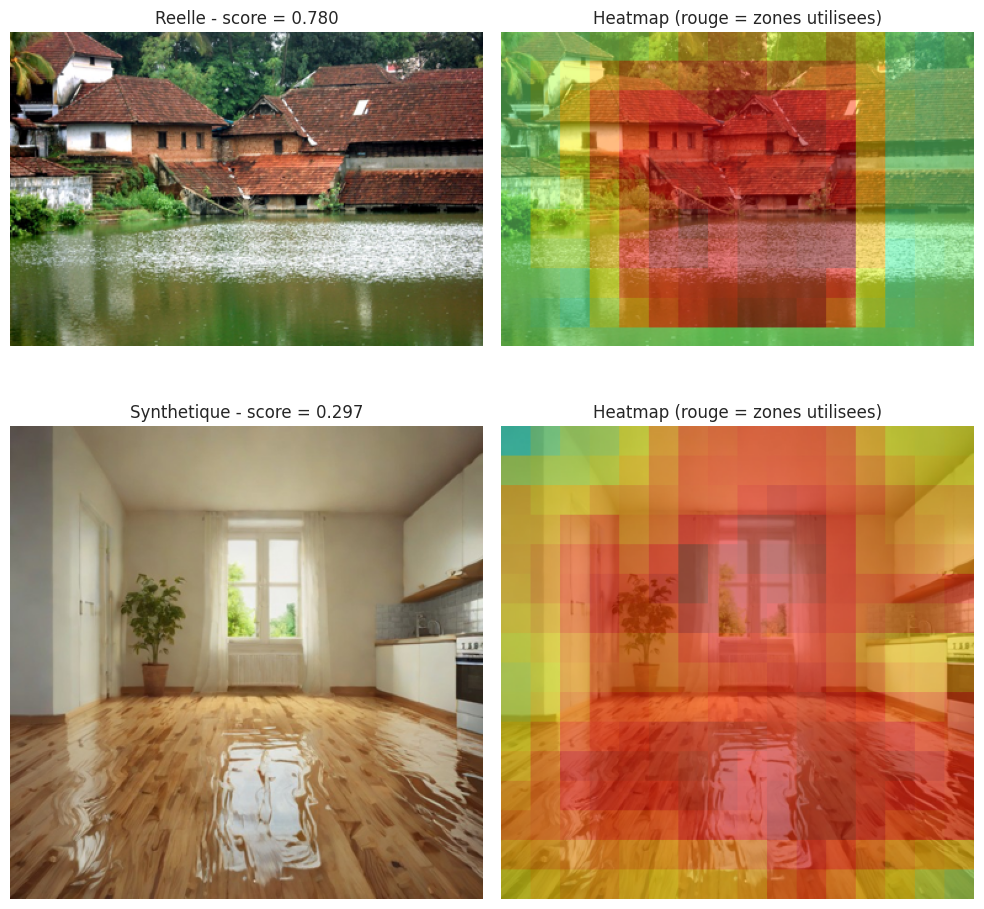

In [25]:
from inference import FraudDetector

detector = FraudDetector(model_dir=str(ROOT / '04_models'), variant=VARIANT)

# Selection d'images du domaine habitation
domain_df = df[df['split'] == 'domain_test'].copy()
if len(domain_df) > 0:
    real_sample = domain_df[domain_df['label'] == 0].sample(1, random_state=0).iloc[0]
    fake_sample = domain_df[domain_df['label'] == 1].sample(1, random_state=0).iloc[0]
    samples = [('Reelle', real_sample), ('Synthetique', fake_sample)]
else:
    print('Pas de domain_test, fallback sur generic_test')
    test_df = df[df['split'] == 'generic_test']
    real_sample = test_df[test_df['label'] == 0].sample(1, random_state=0).iloc[0]
    fake_sample = test_df[test_df['label'] == 1].sample(1, random_state=0).iloc[0]
    samples = [('Reelle', real_sample), ('Synthetique', fake_sample)]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i, (name, row) in enumerate(samples):
    img = Image.open(ROOT / row['image_path']).convert('RGB')
    img.thumbnail((384, 384))
    res = detector.explain_image(img, patch_size=48, stride=24)
    axes[i, 0].imshow(img); axes[i, 0].set_title(f'{name} - score = {res["base_score"]:.3f}'); axes[i, 0].axis('off')
    axes[i, 1].imshow(res['overlay']); axes[i, 1].set_title('Heatmap (rouge = zones utilisees)'); axes[i, 1].axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'occlusion_heatmap_exemples.png', dpi=140, bbox_inches='tight')
plt.show()

## 5. Calibration des seuils de decision

On determine les seuils low/mid/high pour la decision a 3 niveaux :
- score < low : Légitime (auto-validation)
- low <= score < high : A expertiser (escalade)
- score >= high : Fraude probable

In [26]:
from utils.calibration import calibrate_three_thresholds
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Sur le validation set
mask_val = (df['split'] == 'generic_val').values
if mask_val.sum() == 0:
    print("Pas de generic_val, fallback sur generic_test")
    mask_val = (df['split'] == 'generic_test').values
X_val_s = X_s[mask_val]
y_val = df.loc[mask_val, 'label'].values
proba_val = model.predict_proba(X_val_s)[:, 1]

cal = calibrate_three_thresholds(y_val, proba_val, strategy='max_recall_at_precision', min_precision=0.85)
print('Seuils calibres :')
for k, v in cal.items():
    print(f'  {k}: {v}')

Seuils calibres :
  low: 0.012019743212823864
  mid: 0.857199143595693
  high: 0.9071991435956931
  strategy: max_recall_at_precision
  mid_metrics: {'threshold': 0.857199143595693, 'precision': 0.85, 'recall': 0.0913364674278039, 'f1': 0.1649484536080722, 'min_precision_constraint': 0.85}


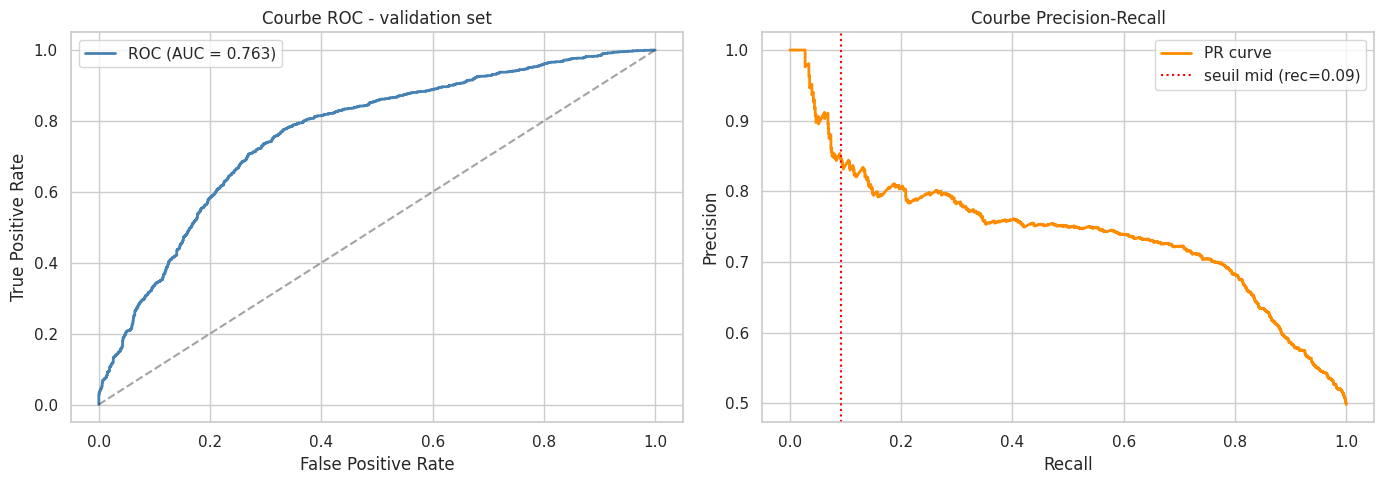

In [27]:
# Courbes ROC et PR avec marquage des seuils
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_val, proba_val)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {auc(fpr, tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Courbe ROC - validation set'); axes[0].legend()

prec, rec, thr = precision_recall_curve(y_val, proba_val)
axes[1].plot(rec, prec, color='darkorange', lw=2, label='PR curve')
axes[1].axvline(cal['mid_metrics']['recall'], color='red', linestyle=':', label=f"seuil mid (rec={cal['mid_metrics']['recall']:.2f})")
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'calibration_roc_pr.png', dpi=140, bbox_inches='tight')
plt.show()

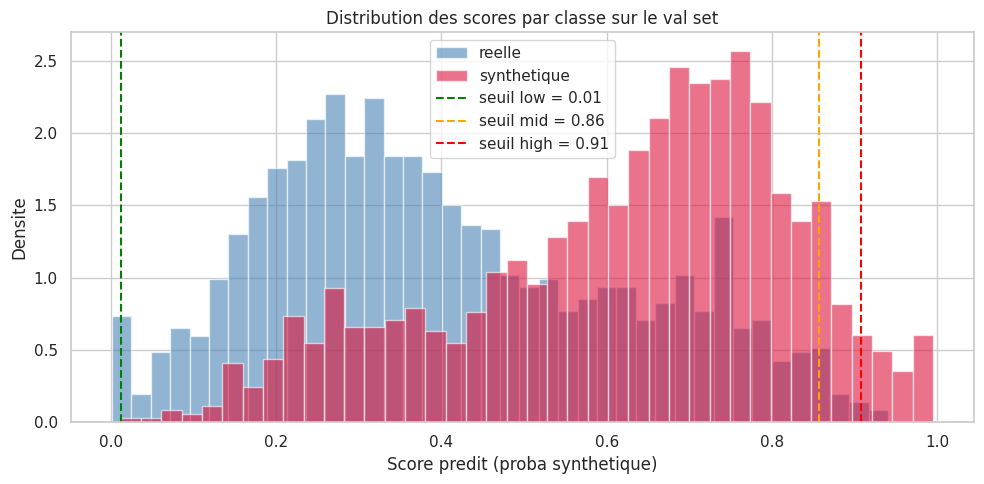

In [28]:
# Distribution des scores par classe avec les seuils
fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [(0, 'steelblue', 'reelle'), (1, 'crimson', 'synthetique')]:
    sub = proba_val[y_val == label]
    ax.hist(sub, bins=40, alpha=0.6, color=color, label=name, density=True)
for t, name, color in [(cal['low'], 'low', 'green'), (cal['mid'], 'mid', 'orange'), (cal['high'], 'high', 'red')]:
    ax.axvline(t, linestyle='--', color=color, label=f'seuil {name} = {t:.2f}')
ax.set_xlabel('Score predit (proba synthetique)'); ax.set_ylabel('Densite')
ax.set_title('Distribution des scores par classe sur le val set')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'calibration_distribution_scores.png', dpi=140, bbox_inches='tight')
plt.show()

In [29]:
# Sauvegarder les seuils pour que l'app Streamlit les recupere
import json
out = ROOT / '04_models' / f'thresholds_image_{VARIANT}.json'
with out.open('w') as f:
    json.dump(cal, f, indent=2)
print('Seuils sauvegardes :', out)

Seuils sauvegardes : /content/drive/MyDrive/Insurance-fraud-detection-AI/04_models/thresholds_image_lite.json
